In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load file
df = pd.read_csv('loan_data Python Data2.csv')

# 1. Calculate Monthly Income from the Log Annual Income
import numpy as np
df['Monthly Income'] = np.exp(df['Log Annual Income']) / 12

# 2. Monthly Debt-to-Income Payment Ratio
# How much of their monthly take-home pay goes JUST to this loan?
df['Installment_as_Pct_Income'] = df['Installments'] / df['Monthly Income']

df.head()

,Credit Policy,Interest Rate,Installments,Log Annual Income,Annual Income,Debt to Income Ratio,FICO Score,Days with Credit Line,Revolving Balance,Revolving Utilization,...,Public Records,Not Fully Paid,Purpose Credit Card,Purpose Debt Consolidation,Purpose Educational,Purpose Home Improvement,Purpose Major Purchase,Purpose Small Business,Monthly Income,Installment_as_Pct_Income
0,1,0.1189,829.10,11.350407,85000.00038,0.1948,737,5640,28854,0.521,...,0,0,0,1,0,0,0,0,7083.333365,0.117049
1,1,0.1071,228.22,11.082143,65000.00007,0.1429,707,2760,33623,0.767,...,0,0,1,0,0,0,0,0,5416.666673,0.042133
2,1,0.1357,366.86,10.373491,31999.99994,0.1163,682,4710,3511,0.256,...,0,0,0,1,0,0,0,0,2666.666662,0.137573
3,1,0.1008,162.34,11.350407,85000.00038,0.0810,712,2700,33667,0.732,...,0,0,0,1,0,0,0,0,7083.333365,0.022919
4,1,0.1426,102.92,11.299732,80799.99964,0.1497,667,4066,4740,0.395,...,0,0,1,0,0,0,0,0,6733.333303,0.015285


In [4]:
# 3. Move the desired column

column_to_move = df.pop('Monthly Income')

# Insert the column at the desired index (e.g., index 0 for the start, index 2 for the third position)
desired_position_index = 5
df.insert(desired_position_index, column_to_move.name, column_to_move)

In [5]:
df.head()

,Credit Policy,Interest Rate,Installments,Log Annual Income,Annual Income,Monthly Income,Debt to Income Ratio,FICO Score,Days with Credit Line,Revolving Balance,...,Delinquencies 2 Years,Public Records,Not Fully Paid,Purpose Credit Card,Purpose Debt Consolidation,Purpose Educational,Purpose Home Improvement,Purpose Major Purchase,Purpose Small Business,Installment_as_Pct_Income
0,1,0.1189,829.10,11.350407,85000.00038,7083.333365,0.1948,737,5640,28854,...,0,0,0,0,1,0,0,0,0,0.117049
1,1,0.1071,228.22,11.082143,65000.00007,5416.666673,0.1429,707,2760,33623,...,0,0,0,1,0,0,0,0,0,0.042133
2,1,0.1357,366.86,10.373491,31999.99994,2666.666662,0.1163,682,4710,3511,...,0,0,0,0,1,0,0,0,0,0.137573
3,1,0.1008,162.34,11.350407,85000.00038,7083.333365,0.0810,712,2700,33667,...,0,0,0,0,1,0,0,0,0,0.022919
4,1,0.1426,102.92,11.299732,80799.99964,6733.333303,0.1497,667,4066,4740,...,1,0,0,1,0,0,0,0,0,0.015285


In [6]:
# 3. Move the desired column
# Remove the column from its original position
column_to_move = df.pop('Installment_as_Pct_Income')

# Insert the column at the desired index (e.g., index 0 for the start, index 2 for the third position)
desired_position_index = 3
df.insert(desired_position_index, column_to_move.name, column_to_move)
df.head()

,Credit Policy,Interest Rate,Installments,Installment_as_Pct_Income,Log Annual Income,Annual Income,Monthly Income,Debt to Income Ratio,FICO Score,Days with Credit Line,...,Inquiries Last 6 Months,Delinquencies 2 Years,Public Records,Not Fully Paid,Purpose Credit Card,Purpose Debt Consolidation,Purpose Educational,Purpose Home Improvement,Purpose Major Purchase,Purpose Small Business
0,1,0.1189,829.10,0.117049,11.350407,85000.00038,7083.333365,0.1948,737,5640,...,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,0.042133,11.082143,65000.00007,5416.666673,0.1429,707,2760,...,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,0.137573,10.373491,31999.99994,2666.666662,0.1163,682,4710,...,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,0.022919,11.350407,85000.00038,7083.333365,0.0810,712,2700,...,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,0.015285,11.299732,80799.99964,6733.333303,0.1497,667,4066,...,0,1,0,0,1,0,0,0,0,0


In [7]:
# 3. Save to a new CSV file
# 'index=False' prevents Pandas from adding a new column for row numbers
df.to_csv('loan_data Python Data3.csv', index=False)

In [12]:
# Handeling Class Imbalance
# Data is 8,045 not paid (0) vs. 1,533 fully paid (1), roughly an 84/16 split.
# Fix this by Oversampling - make articifial random copies of the minority group (loans NOT paid back) until both groups are equal in size

from sklearn.utils import resample

# Split the data into the two groups
minority = df[df['Not Fully Paid'] == 1]   # the 1,533 defaulted loans
majority = df[df['Not Fully Paid'] == 0]   # the 8,045 paid loans

# Make copies of the minority until it matches the majority size
minority_upsampled = resample(minority, 
                               replace=True,        # allow copying same rows
                               n_samples=len(majority),  # match majority count
                               random_state=42)     # makes results reproducible

# Combine them back into one balanced dataset
df_balanced = pd.concat([majority, minority_upsampled])


,Credit Policy,Interest Rate,Installments,Installment_as_Pct_Income,Log Annual Income,Annual Income,Monthly Income,Debt to Income Ratio,FICO Score,Days with Credit Line,...,Inquiries Last 6 Months,Delinquencies 2 Years,Public Records,Not Fully Paid,Purpose Credit Card,Purpose Debt Consolidation,Purpose Educational,Purpose Home Improvement,Purpose Major Purchase,Purpose Small Business
0,1,0.1189,829.10,0.117049,11.350407,85000.00038,7083.333365,0.1948,737,5640,...,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,0.042133,11.082143,65000.00007,5416.666673,0.1429,707,2760,...,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,0.137573,10.373491,31999.99994,2666.666662,0.1163,682,4710,...,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,0.022919,11.350407,85000.00038,7083.333365,0.0810,712,2700,...,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,0.015285,11.299732,80799.99964,6733.333303,0.1497,667,4066,...,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,0.1461,344.76,0.021216,12.180755,195000.00050,16250.000040,0.1039,672,10474,...,2,0,0,1,0,0,0,0,0,0
9574,0,0.1253,257.70,0.044817,11.141862,68999.99975,5749.999979,0.0021,722,4380,...,5,0,0,1,0,0,0,0,0,0
9575,0,0.1071,97.81,0.029343,10.596635,39999.99988,3333.333323,0.1309,687,3450,...,8,0,0,1,0,1,0,0,0,0
9576,0,0.1600,351.58,0.084379,10.819778,49999.99978,4166.666648,0.1918,692,1800,...,5,0,0,1,0,0,0,1,0,0


In [13]:
# Verifiy number of new rows
df_balanced.shape

(16090, 22)

In [14]:
# Scaling and Normalization
# Use (StandardScaler) to rescale each column so its averages become 0 and its spread becoems 1.
# Essentially converting the values to curved values.

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate your features (inputs) from your target (what you're predicting)
features = df_balanced.drop('Not Fully Paid', axis=1)  # everything EXCEPT the target
target = df_balanced['Not Fully Paid']                  # just the target column

# Split into training data (model learns from this) and test data (model is graded on this)
X_train, X_test, y_train, y_test = train_test_split(features, target, 
                                                      test_size=0.2,      # 20% held back for testing
                                                      random_state=42)    # reproducible split

# Create the scaler and apply it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn the scale FROM training data, then apply it
X_test_scaled = scaler.transform(X_test)         # apply that SAME scale to test data

In [15]:
# Verify Results

# Before scaling - see original values
print("BEFORE SCALING:")
print(pd.DataFrame(X_train).describe().round(2))

print("AFTER SCALING:")
print(pd.DataFrame(X_train_scaled).describe().round(2))

BEFORE SCALING:
       Credit Policy  Interest Rate  Installments  Installment_as_Pct_Income  \
count       12872.00       12872.00      12872.00                   12872.00   
mean            0.75           0.13        326.12                       0.07   
std             0.44           0.03        212.88                       0.05   
min             0.00           0.06         15.67                       0.00   
25%             0.00           0.11        165.85                       0.04   
50%             1.00           0.13        273.70                       0.06   
75%             1.00           0.14        452.62                       0.10   
max             1.00           0.22        940.14                       0.54   

       Log Annual Income  Annual Income  Monthly Income  Debt to Income Ratio  \
count           12872.00       12872.00        12872.00              12872.00   
mean               10.90       67279.35         5606.61                  0.13   
std                 

In [16]:
scaled_df = pd.DataFrame(X_train_scaled, columns=features.columns)
scaled_df.head(10)

,Credit Policy,Interest Rate,Installments,Installment_as_Pct_Income,Log Annual Income,Annual Income,Monthly Income,Debt to Income Ratio,FICO Score,Days with Credit Line,...,Revolving Utilization,Inquiries Last 6 Months,Delinquencies 2 Years,Public Records,Purpose Credit Card,Purpose Debt Consolidation,Purpose Educational,Purpose Home Improvement,Purpose Major Purchase,Purpose Small Business
0,-1.710085,0.082803,1.390987,0.552366,0.561929,0.173795,0.173795,0.772877,0.851242,1.233994,...,1.404336,0.042208,-0.319110,-0.269969,-0.361950,-0.821687,-0.203529,-0.265902,-0.207837,-0.301409
1,0.584766,-0.133551,-0.278529,-0.822951,0.893907,0.479002,0.479002,-1.083315,-0.507149,-0.171510,...,0.618158,0.423203,1.585195,-0.269969,2.762812,-0.821687,-0.203529,-0.265902,-0.207837,-0.301409
2,0.584766,0.343920,1.420112,0.538347,0.587974,0.195476,0.195476,-0.316627,0.036208,-0.009537,...,-0.205783,-0.338788,1.585195,-0.269969,-0.361950,-0.821687,-0.203529,-0.265902,-0.207837,-0.301409
3,0.584766,-0.044025,-1.217553,-1.260604,0.156147,-0.121405,-0.121405,-1.262017,-0.507149,-0.357598,...,-1.050322,-0.338788,-0.319110,-0.269969,-0.361950,1.217009,-0.203529,-0.265902,-0.207837,-0.301409
4,0.584766,-0.678167,-1.148449,-1.196115,0.156147,-0.121405,-0.121405,-0.074515,-0.371310,0.281451,...,-1.472592,-0.338788,5.393807,-0.269969,-0.361950,-0.821687,-0.203529,-0.265902,-0.207837,-0.301409
5,0.584766,0.101454,-0.346223,-0.428696,0.129765,-0.138083,-0.138083,0.855022,-0.914666,-0.241444,...,0.350378,0.423203,-0.319110,3.368822,-0.361950,1.217009,-0.203529,-0.265902,-0.207837,-0.301409
6,-1.710085,1.119810,2.453607,3.889110,-0.441547,-0.438286,-0.438286,-0.290686,0.443725,-0.032045,...,1.713314,0.804199,-0.319110,-0.269969,-0.361950,1.217009,-0.203529,-0.265902,-0.207837,-0.301409
7,0.584766,0.071612,0.363130,1.477484,-0.689730,-0.538287,-0.538287,-0.240246,-0.507149,1.451029,...,-0.020396,-0.338788,7.298113,-0.269969,2.762812,-0.821687,-0.203529,-0.265902,-0.207837,-0.301409
8,0.584766,-1.241433,-0.781606,-0.553634,-0.403721,-0.421608,-0.421608,0.927079,0.987081,0.896384,...,-0.322508,-0.719783,-0.319110,-0.269969,-0.361950,-0.821687,-0.203529,-0.265902,-0.207837,-0.301409
9,0.584766,-0.163393,-1.250296,-1.291161,0.156147,-0.121405,-0.121405,1.000577,0.715403,-0.309368,...,1.634353,-0.719783,-0.319110,-0.269969,-0.361950,-0.821687,-0.203529,-0.265902,-0.207837,-0.301409


Matplotlib is building the font cache; this may take a moment.


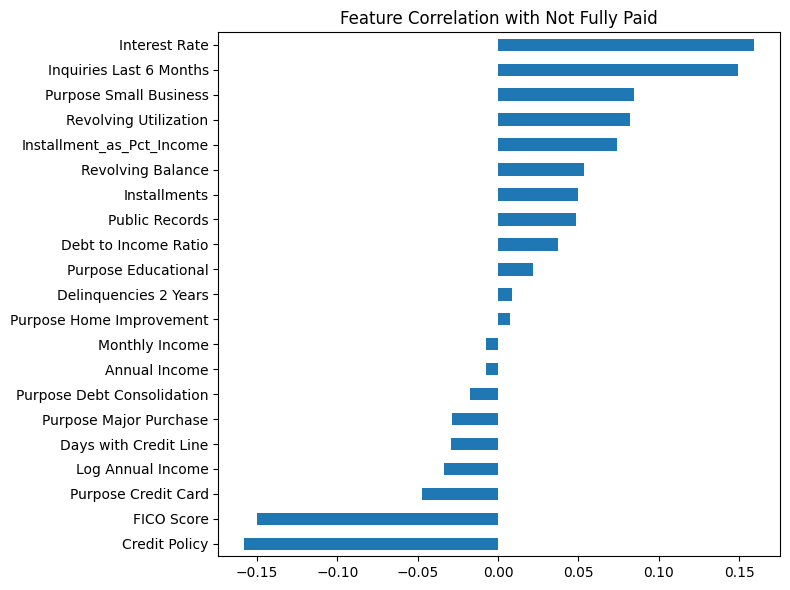

In [18]:
# Correlation Analysis
# Create a grid displaying how each feature correlates tot eh target (NOT paid back)

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlations between every column and every other column
corr = df[df.columns].corr()

# Pull out just the row showing correlation with your target
target_corr = corr['Not Fully Paid'].drop('Not Fully Paid').sort_values()

# Plot it as a horizontal bar chart
plt.figure(figsize=(8, 6))
target_corr.plot(kind='barh')
plt.title('Feature Correlation with Not Fully Paid')
plt.tight_layout()
plt.savefig('correlation_chart.png')   # saves the chart as an image file

In [19]:
# Logistic Regression
# Create a model with the balanced data, that is self adjusting to 1000 iterations. 
# Have model read training data and adjust
# Run the test data through the trained model and output predictions
# Print scorecard showing Precision, Recall, and F1-score for each class

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Build and train the model
model = LogisticRegression(class_weight='balanced',  # penalize missing minority class more
                            max_iter=1000)            # give it enough attempts to converge

model.fit(X_train_scaled, y_train)   # model "learns" from training data

# Make predictions on the test data the model has NEVER seen
y_pred = model.predict(X_test_scaled)

# Grade the model's performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.64      0.62      1578
           1       0.64      0.61      0.62      1640

    accuracy                           0.62      3218
   macro avg       0.62      0.62      0.62      3218
weighted avg       0.62      0.62      0.62      3218



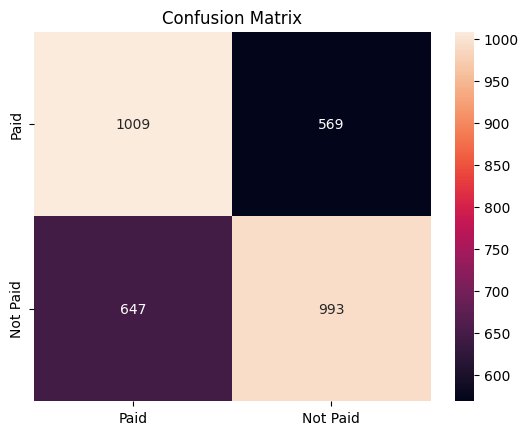

In [20]:
# Understanding output - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Paid', 'Not Paid'], 
            yticklabels=['Paid', 'Not Paid'])
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

In [21]:
print("\n--- Interest Rate by Loan Outcome ---")
rate_stats = df.groupby('Not Fully Paid')['Interest Rate'].agg(['mean', 'median'])
print(rate_stats)
print("(Values shown as decimals: 0.12 = 12%)")


--- Interest Rate by Loan Outcome ---
                    mean  median
Not Fully Paid                  
0               0.120770  0.1218
1               0.132452  0.1316
(Values shown as decimals: 0.12 = 12%)


In [22]:
# --- Finding 3: Installment as % of Income by loan outcome ---
print("\n--- Installment_as_Pct_Income by Loan Outcome ---")
pct_stats = df.groupby('Not Fully Paid')['Installment_as_Pct_Income'].agg(['mean', 'median'])
print(pct_stats)
paid_avg   = df[df['Not Fully Paid']==0]['Installment_as_Pct_Income'].mean() * 100
default_avg = df[df['Not Fully Paid']==1]['Installment_as_Pct_Income'].mean() * 100
print(f"\nFully Paid average:     {paid_avg:.1f}% of monthly income")
print(f"Not Fully Paid average: {default_avg:.1f}% of monthly income")
 


--- Installment_as_Pct_Income by Loan Outcome ---
                    mean    median
Not Fully Paid                    
0               0.066396  0.057797
1               0.075269  0.065367

Fully Paid average:     6.6% of monthly income
Not Fully Paid average: 7.5% of monthly income
